In [1]:
#import keras
import tensorflow as tf
from tensorflow import keras
from IPython.display import Image
import matplotlib.pyplot as plt
#from keras import layers
#from keras import ops
from tensorflow.keras import layers
import os
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
from keras.callbacks import CSVLogger
from PIL import Image
import seaborn as sns
import json
import tqdm
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

2026-05-11 21:24:58.315418: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


<h1>Analyzing the dataset</h1>

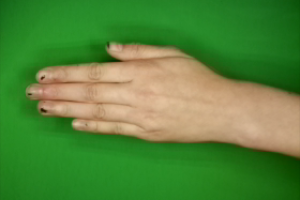

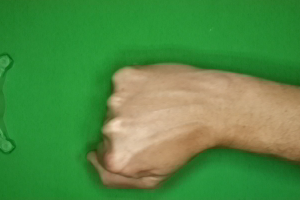

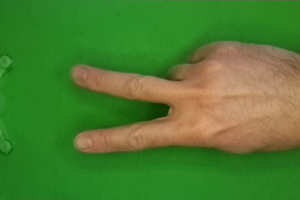

In [2]:
paper= Image.open('./train/paper/2IOsxsG8AaxntdJM.png')
paper.show()
rock= Image.open('./train/rock/2DdERUV7Te8ivywq.png')
rock.show()
scissors= Image.open('./train/scissors/2DEYFsJ27UgVqv3W.png')
scissors.show()



In [3]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="training",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="validation",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

temp_size = len(temp_ds)

val_size = temp_size // 2

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)


Found 2188 files belonging to 3 classes.
Using 1532 files for training.


I0000 00:00:1778527501.886493  194955 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7535 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:07:00.0, compute capability: 8.6


Found 2188 files belonging to 3 classes.
Using 656 files for validation.


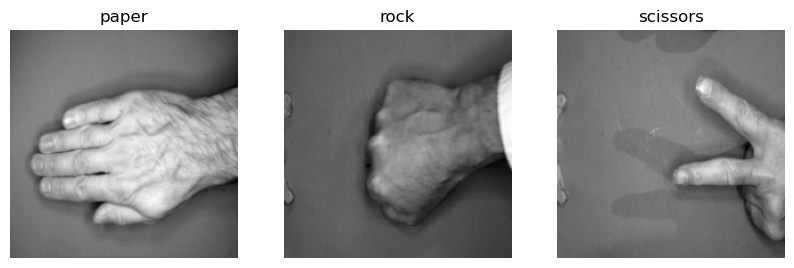

In [4]:
class_names = train_ds.class_names
# Display one image per class
shown_classes = set()
plt.figure(figsize=(10, 4))
for images, labels in train_ds.unbatch():
    label = labels.numpy()
    if label not in shown_classes:
        plt.subplot(1, len(class_names), len(shown_classes) + 1)
        plt.imshow(images.numpy().squeeze(), cmap="gray")  
        plt.title(class_names[label])
        plt.axis("off")
        shown_classes.add(label)
    if len(shown_classes) == len(class_names):
        break
plt.show()

<h2>Model 1 architecture and training</h2>

In [5]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.4),
    layers.RandomContrast(0.4)
])

In [6]:

if os.path.exists("model_1.keras"):
    model_1 = keras.models.load_model("model_1.keras")
    history_1 = pd.read_csv('./training_1.log',sep=',',engine='python')
else:
    model_1 = keras.Sequential(
        [
        
        layers.Rescaling(1./255),
        layers.Resizing(96, 96),        
       layers.Conv2D(16, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(96, 96, 1)),
       layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu",kernel_initializer='he_normal'),
        layers.Dense(3,activation='softmax')
    
        ]
    )
    csv_logger_1 = CSVLogger('training_1.log', separator=',', append=False)
    model_1.summary()
    model_1.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    history_1=model_1.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[csv_logger_1])
    history_1=history_1.history

/home/loren/miniconda3/envs/StatML/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

13/48 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3152 - loss: 4.3316

I0000 00:00:1778527507.286589  195102 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


45/48 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3871 - loss: 2.7341

2026-05-11 21:25:08.824577: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_317', 20 bytes spill stores, 20 bytes spill loads



48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.4615 - loss: 1.6205 - val_accuracy: 0.6687 - val_loss: 0.8667
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6913 - loss: 0.8159 - val_accuracy: 0.6969 - val_loss: 0.8562
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7526 - loss: 0.6838 - val_accuracy: 0.8188 - val_loss: 0.5888
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8290 - loss: 0.5195 - val_accuracy: 0.8281 - val_loss: 0.5533
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8368 - loss: 0.4782 - val_accuracy: 0.8156 - val_loss: 0.5171
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8570 - loss: 0.4364 - val_accuracy: 0.8438 - val_loss: 0.4392
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8479 - loss: 0.4192 - val_accuracy: 0.8562 - val_loss: 0.4134
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9093 - loss: 0.3107 - val_accuracy: 0.8656 - val_loss: 0.

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


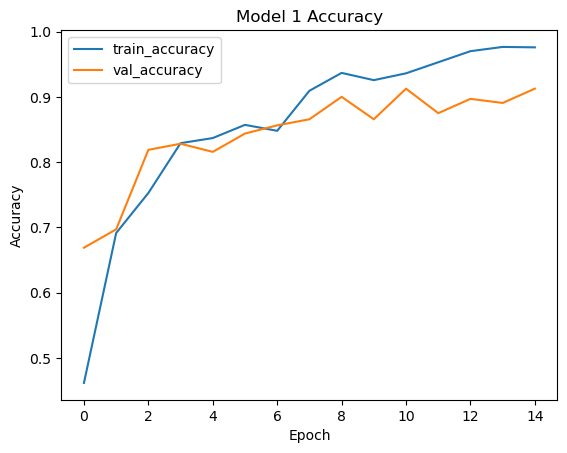

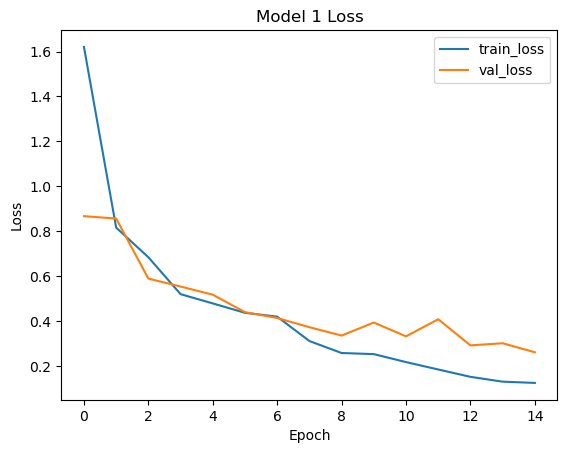

In [7]:
print(history_1.keys())
plt.title("Model 1 Accuracy")
plt.plot(history_1["accuracy"], label="train_accuracy")
plt.plot(history_1["val_accuracy"], label="val_accuracy")
#plt.ylim(0.8, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.title("Model 1 Loss")
plt.plot(history_1["loss"], label="train_loss")
plt.plot(history_1["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

<h3>Model 1 prediction</h3> 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step
Predicted label: paper
Actual label: paper


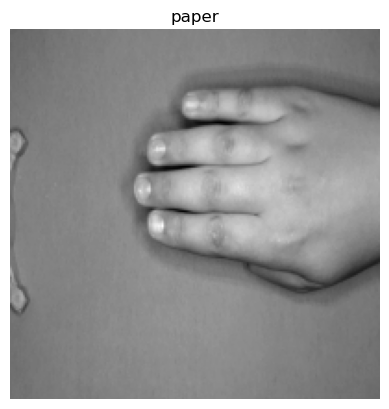

2026-05-11 21:25:27.028644: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_1.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

<h2>Model 2 architecture and training</h2>

In [9]:

if os.path.exists("model_2.keras"):
    model_2 = keras.models.load_model("model_2.keras")
    history_2 = pd.read_csv('./training_2.log',sep=',',engine='python')
else:
    model_2 = keras.Sequential(
        [
            data_augmentation,
        layers.Rescaling(1./255),
       layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(128, 128, 1)),
       layers.MaxPooling2D((2, 2)),
       layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
       layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation="relu",kernel_initializer='he_normal'),
        layers.Dense(64, activation="relu",kernel_initializer='he_normal'),

        layers.Dense(3,activation='softmax')

        ]
    )
    csv_logger_2 = CSVLogger('training_2.log', separator=',', append=False)
    model_2.summary()

    model_2.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history_2=model_2.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[csv_logger_2])
    history_2=history_2.history

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.3975 - loss: 6.2080 - val_accuracy: 0.4344 - val_loss: 0.9605
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5836 - loss: 0.9294 - val_accuracy: 0.7875 - val_loss: 0.8872
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6697 - loss: 0.7934 - val_accuracy: 0.8500 - val_loss: 0.6722
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ -1s -17184us/step - accuracy: 0.7258 - loss: 0.6788 - val_accuracy: 0.6781 - val_loss: 0.6490
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7892 - loss: 0.5761 - val_accuracy: 0.8906 - val_loss: 0.4702
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8231 - loss: 0.4864 - val_accuracy: 0.7844 - val_loss: 0.4658
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8544 - loss: 0.4018 - val_accuracy: 0.8906 - val_loss: 0.3645
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8766 - loss: 0.3363 - val_accuracy: 0.943

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


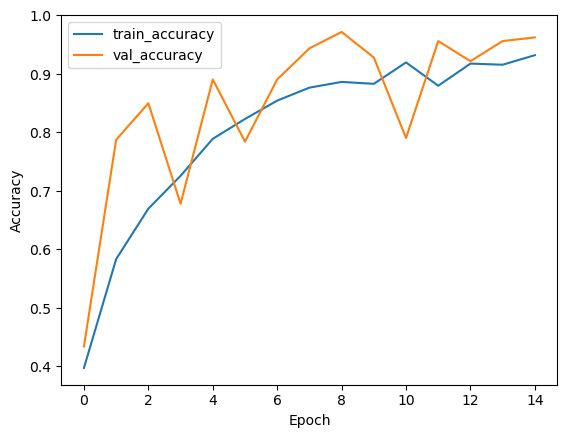

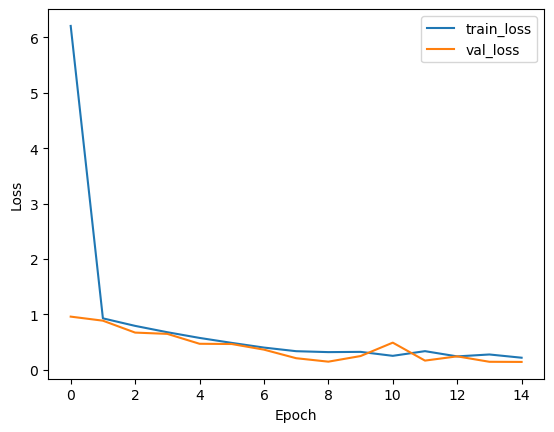

In [10]:
print(history_2.keys())
plt.plot(history_2["accuracy"], label="train_accuracy")
plt.plot(history_2["val_accuracy"], label="val_accuracy")
#plt.ylim(0.9, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.plot(history_2["loss"], label="train_loss")
plt.plot(history_2["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

<h3>Model 2 prediction </h3>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Predicted label: rock
Actual label: rock


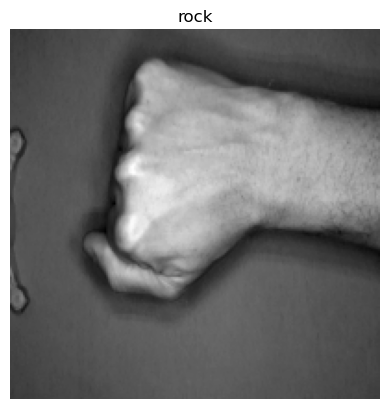

2026-05-11 21:25:55.445886: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_2.predict(image[None, ...])
    

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

<h2>Model 3 architecture and training</h2>

<h3>Finding The best learning rate using grid-search</h3>

In [12]:

if os.path.exists("best_lr.json"):
    best_params = json.load(open('best_lr.json', 'r'))
    best_lr = best_params['best_lr']
    best_val_acc = best_params['best_val_acc']
else:
    lr_arr=[1e-5,2e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]
    best_val_acc = 0
    best_lr = None
    for lr in lr_arr:
        model_4 = keras.Sequential([
            data_augmentation,
            layers.Rescaling(1./255),

            layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(200, 200, 1)),
            layers.MaxPooling2D((2, 2)), 

            layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(128, (3, 3), activation='relu',kernel_initializer='he_normal'),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(256, (3, 3), activation='relu',kernel_initializer='he_normal'),
            layers.MaxPooling2D((2, 2)),


            layers.Flatten(),
            layers.Dense(1024, activation="relu",name='dense_1',kernel_initializer='he_normal'),
            layers.Dropout(0.2),
            layers.Dense(512, activation="relu",name='dense_2',kernel_initializer='he_normal'),
            layers.Dropout(0.2),
            layers.Dense(3, activation='softmax')
        ])

        model_4.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]

        )
        
        history_4=model_4.fit(train_ds, validation_data=val_ds, epochs=15)
        history_4=history_4.history

        # Update best learning rate if current model performs better
        if max(history_4['val_accuracy'])  > best_val_acc:
            best_val_acc = max(history_4['val_accuracy'])
            best_lr = lr
    json.dump({'best_lr': best_lr, 'best_val_acc': best_val_acc}, open('best_lr.json', 'w'))


Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.3714 - loss: 1.1633 - val_accuracy: 0.3906 - val_loss: 1.0290
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.4817 - loss: 1.0346 - val_accuracy: 0.6406 - val_loss: 0.9267
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5705 - loss: 0.9471 - val_accuracy: 0.7281 - val_loss: 0.8007
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6351 - loss: 0.8459 - val_accuracy: 0.8656 - val_loss: 0.6990
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6860 - loss: 0.7835 - val_accuracy: 0.8000 - val_loss: 0.6310
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7461 - loss: 0.6735 - val_accuracy: 0.9062 - val_loss: 0.4780
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7533 - loss: 0.6318 - val_accuracy: 0.8375 - val_loss: 0.5003
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7826 - loss: 0.5776 - val_accuracy: 0.8813 - v

In [13]:
early_stop = EarlyStopping(
    monitor='val_accuracy',   # or 'val_loss'
    mode='max',
    patience=3,
    restore_best_weights=True
)

lr_sched = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)


ckpt = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

In [14]:
if os.path.exists("model_3.keras"):
    model_3 = keras.models.load_model("model_3.keras")
    history_3 = pd.read_csv('./training_3.log',sep=',',engine='python')
else:
    model_3 = keras.Sequential([

        data_augmentation,
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation="relu",kernel_initializer='he_normal', input_shape=(200, 200, 1)),
        layers.MaxPooling2D((2, 2)), 

        layers.Conv2D(64, (3, 3), activation="relu",kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu',kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu',kernel_initializer='he_normal'),
        layers.MaxPooling2D((2, 2)),
       

        layers.Flatten(),
        layers.Dense(1024, activation="relu",name='dense_1',kernel_initializer='he_normal'),
        layers.Dropout(0.2),
        layers.Dense(512, activation="relu",name='dense_2',kernel_initializer='he_normal'),
        layers.Dropout(0.2),
        layers.Dense(3, activation='softmax')
    ])
    csv_logger_3 = CSVLogger('training_3.log', separator=',', append=False)

    model_3.summary()
    model_3.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
        
    )
    history_3=model_3.fit(train_ds, validation_data=val_ds, epochs=15, callbacks=[csv_logger_3, early_stop, lr_sched, ckpt])
    history_3=history_3.history

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_9 (Rescaling)         │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 198, 198, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │    26,215,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,129,603 (103.49 MB)

 Trainable params: 27,129,603 (103.49 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.4974 - loss: 2.0609 - val_accuracy: 0.7750 - val_loss: 0.7295 - learning_rate: 0.0010
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.6919 - loss: 0.7500 - val_accuracy: 0.8594 - val_loss: 0.4499 - learning_rate: 0.0010
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.7794 - loss: 0.5422 - val_accuracy: 0.9156 - val_loss: 0.2984 - learning_rate: 0.0010
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8172 - loss: 0.4515 - val_accuracy: 0.8438 - val_loss: 0.3962 - learning_rate: 0.0010
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.8466 - loss: 0.4266 - val_accuracy: 0.9344 - val_loss: 0.2360 - learning_rate: 0.0010
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8544 - loss: 0.3993 - val_accuracy: 0.9312 - val_loss: 0.2135 - learning_rate: 0.0010
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.8597 - loss: 0.3880 - val_ac

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


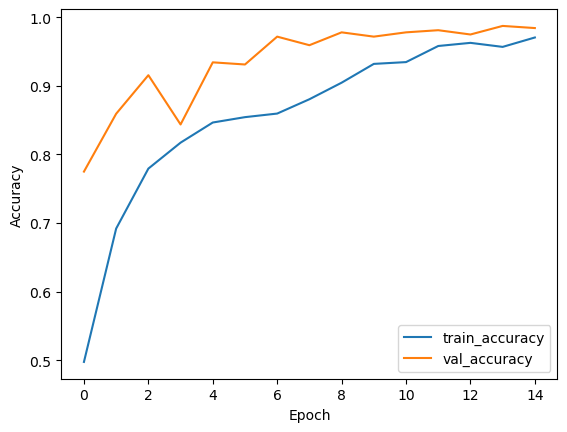

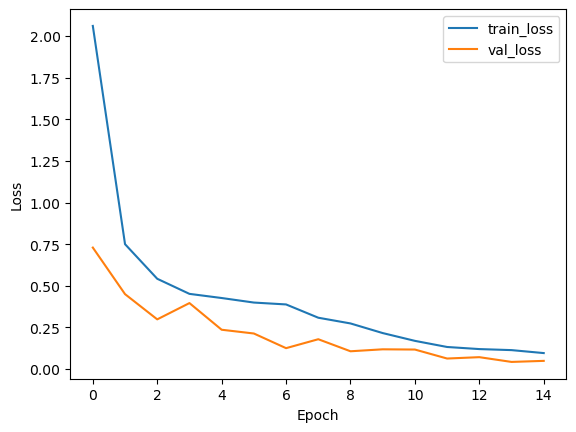

In [15]:
print(history_3.keys())
plt.plot(history_3["accuracy"], label="train_accuracy")
plt.plot(history_3["val_accuracy"], label="val_accuracy")
#plt.ylim(0.9, 1.0) 
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()
plt.plot(history_3["loss"], label="train_loss")
plt.plot(history_3["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

<h3>Model 3 prediction</h3>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Predicted label: rock
Actual label: rock


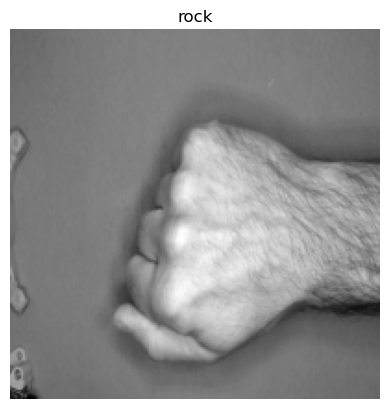

In [16]:

for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_3.predict(image[None, ...])
    

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()
    

<h2>Models testing</h2>

In [17]:
y_test=[]
img_test=[]
y_pred_1=[]
y_pred_2=[]
y_pred_3=[]
for images, labels in test_ds.unbatch():
    y_test.append(labels.numpy())
    img_test.append(images.numpy())
    y_pred_1.append(np.argmax(model_1.predict(images[None, ...])[0]))
    y_pred_2.append(np.argmax(model_2.predict(images[None, ...])[0]))
    y_pred_3.append(np.argmax(model_3.predict(images[None, ...])[0]))

y_test = np.array(y_test)
img_test = np.array(img_test)
y_pred_1 = np.array(y_pred_1)
y_pred_2 = np.array(y_pred_2)
y_pred_3 = np.array(y_pred_3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━

2026-05-11 21:31:22.734663: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<h2>Performance evaluation</h2>

In [18]:
result_1=confusion_matrix(y_test, y_pred_1,labels=[0,1,2])

In [19]:
incorrect_indices_1 = np.where(y_pred_1 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_1)} out of {len(y_test)}")

Incorrectly classified samples: 34 out of 336


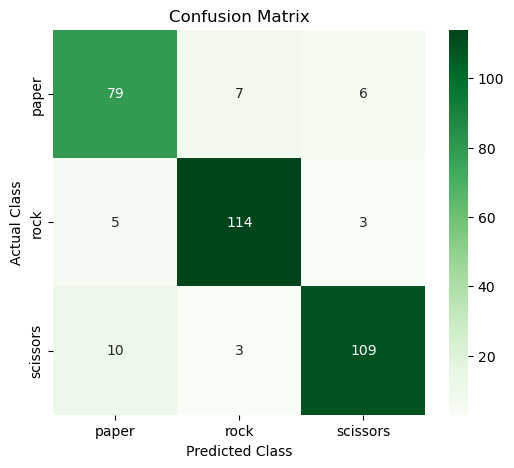

In [20]:

p=[('Predicted', x)  for x in class_names]
b=[('Actual', x)  for x in class_names]
df = pd.DataFrame(result_1, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model1_cf=np.array(pd.DataFrame(result_1,columns=class_names,index=class_names))
plt.figure(figsize=(6,5))
sns.heatmap(result_1, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step


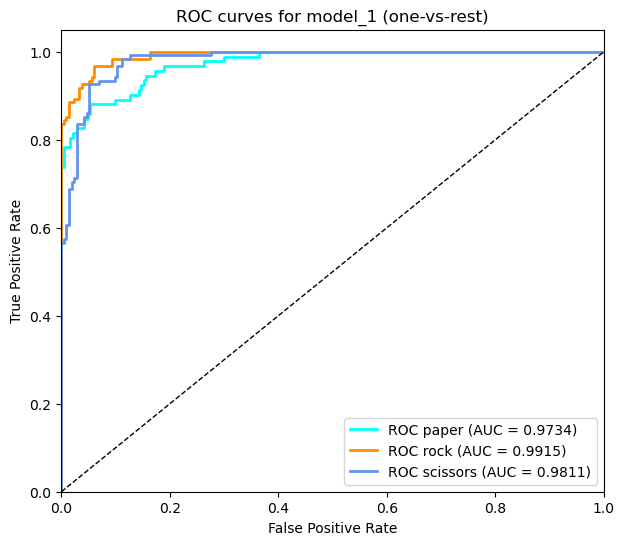

AUC per class:
  paper: 0.9734
  rock: 0.9915
  scissors: 0.9811
Micro AUC: 0.9833
Macro AUC: 0.9820


In [21]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# If model_1 needs 96x96 and you want to resize explicitly, uncomment:
# img_test_resized = tf.image.resize(img_test, (96, 96)).numpy()
# y_score = model_1.predict(img_test_resized)

y_score = model_1.predict(img_test)  # predicted probabilities

fpr = dict(); tpr = dict(); roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

roc_auc["micro"] = roc_auc_score(y_test_bin, y_score, average="micro", multi_class="ovr")
roc_auc["macro"] = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")

colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
plt.figure(figsize=(7,6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.4f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlim([0.0,1.0]); plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves for model_1 (one-vs-rest)')
plt.legend(loc='lower right')
plt.show()

print('AUC per class:')
for i in range(n_classes):
    print(f'  {class_names[i]}: {roc_auc[i]:.4f}')
print(f"Micro AUC: {roc_auc['micro']:.4f}")
print(f"Macro AUC: {roc_auc['macro']:.4f}")


In [22]:
result_2=confusion_matrix(y_test, y_pred_2)

In [23]:
incorrect_indices_2 = np.where(y_pred_2 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_2)} out of {len(y_test)}")

Incorrectly classified samples: 13 out of 336


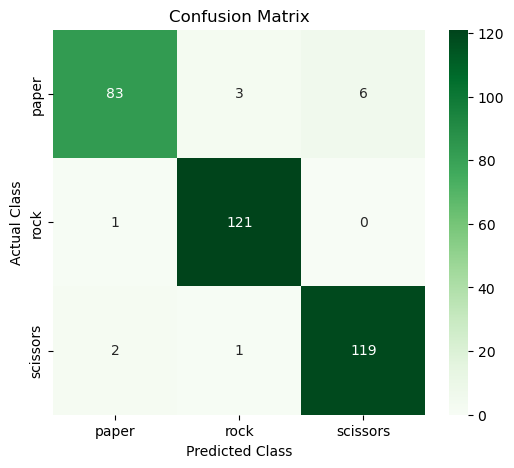

In [24]:
p=[('Predicted', x)  for x in class_names]
b=[('Real', x)  for x in class_names]
df = pd.DataFrame(result_2, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model2_cf=np.array(pd.DataFrame(result_2,columns=class_names,index=class_names))

plt.figure(figsize=(6,5))
sns.heatmap(result_2, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


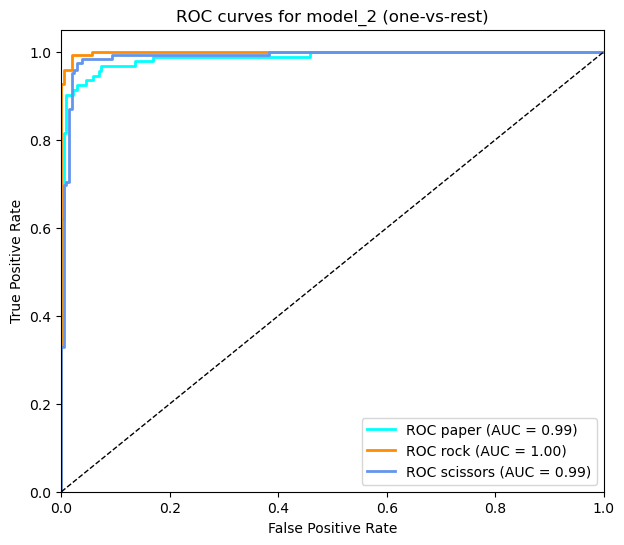

AUC per class:
  paper: 0.9870
  rock: 0.9988
  scissors: 0.9895
Micro AUC: 0.9924
Macro AUC: 0.9918


In [25]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))
y_score = model_2.predict(img_test)  # predicted probabilities

fpr = dict(); tpr = dict(); roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

roc_auc["micro"] = roc_auc_score(y_test_bin, y_score, average="micro", multi_class="ovr")
roc_auc["macro"] = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")

colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
plt.figure(figsize=(7,6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlim([0.0,1.0]); plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves for model_2 (one-vs-rest)')
plt.legend(loc='lower right')
plt.show()

print('AUC per class:')
for i in range(n_classes):
    print(f'  {class_names[i]}: {roc_auc[i]:.4f}')
print(f"Micro AUC: {roc_auc['micro']:.4f}")
print(f"Macro AUC: {roc_auc['macro']:.4f}")

In [26]:

result_3=confusion_matrix(y_test, y_pred_3)

In [27]:
incorrect_indices_3 = np.where(y_pred_3 != y_test)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_3)} out of {len(y_test)}")


Incorrectly classified samples: 4 out of 336


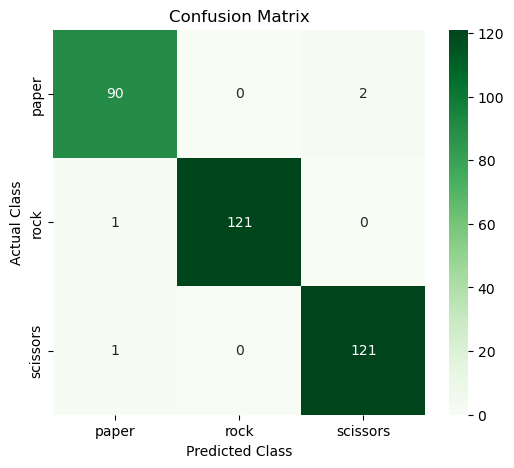

In [28]:
p=[('Predicted', x)  for x in class_names]
b=[('Real', x)  for x in class_names]
df = pd.DataFrame(result_3, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model3_cf=np.array(pd.DataFrame(result_3,columns=class_names,index=class_names))

plt.figure(figsize=(6,5))
sns.heatmap(result_3, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


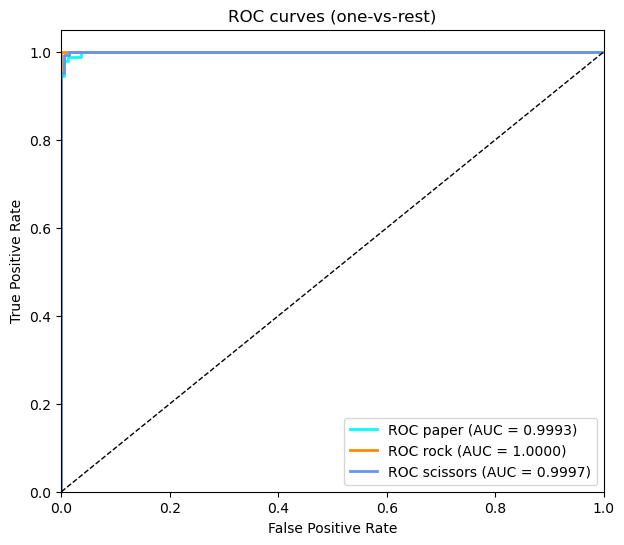

AUC per class:
  paper: 0.9993
  rock: 1.0000
  scissors: 0.9997
Micro AUC: 0.9998
Macro AUC: 0.9997


In [29]:
from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score

# number of classes
n_classes = 3

# binarize true labels (shape: [n_samples, n_classes])
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# predicted probabilities from the model (model already includes Rescaling)
y_score = model_3.predict(img_test)  # shape: (n_samples, n_classes)

# compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes): #One vs rest approach, treat class i as positive and the rest as negative
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# micro- and macro-averaged AUC (multiclass)
#micro auc: aggregates contributions from all classes and computes a global average
# macro auc: computes AUC for each class and averages them, treating all classes equally regardless of their frequency  
roc_auc["micro"] = roc_auc_score(y_test_bin, y_score, average="micro", multi_class="ovr")
roc_auc["macro"] = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")

# Plot per-class ROC
colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
plt.figure(figsize=(7,6))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves (one-vs-rest)')
plt.legend(loc='lower right')
plt.show()

# Print summary AUCs
print('AUC per class:')
for i in range(n_classes):
    print(f'  {class_names[i]}: {roc_auc[i]:.4f}')
print(f"Micro AUC: {roc_auc['micro']:.4f}")
print(f"Macro AUC: {roc_auc['macro']:.4f}")

<h2>Incorrect prediction analisys</h2>

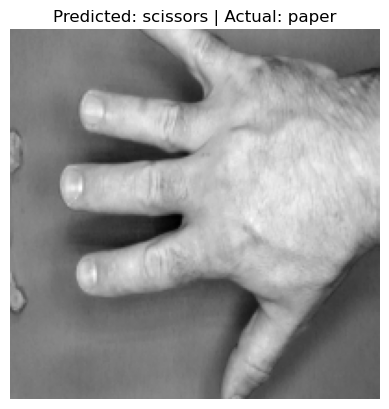

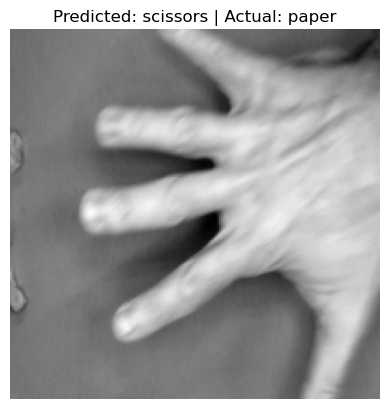

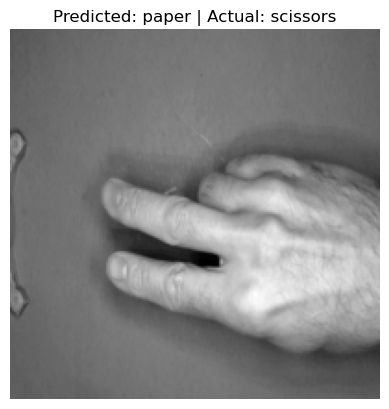

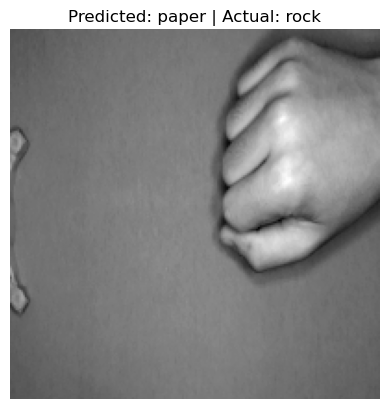

In [30]:
for idx in incorrect_indices_3:
    img=img_test[idx].squeeze()
    plt.imshow(img, cmap="gray")
    plt.title(f'Predicted: {class_names[y_pred_3[idx]]} | Actual: {class_names[y_test[idx]]}')
    plt.axis("off")
    plt.show()

<h3>Performance metrics</h3>

In [31]:
m1_true_pos=np.diag(model1_cf)
m1_false_pos=np.sum(model1_cf, axis=0)-m1_true_pos
m1_false_neg=np.sum(model1_cf, axis=1)-m1_true_pos
m1_true_neg=np.sum(model1_cf)-m1_true_pos-m1_false_pos-m1_false_neg

m1_precision =m1_true_pos / (m1_true_pos + m1_false_pos)
m1_recall =m1_true_pos / (m1_true_pos + m1_false_neg)
m1_accuracy = np.sum(m1_true_pos) / np.sum(model1_cf)
m1_f1_score = 2 * (m1_precision * m1_recall) / (m1_precision + m1_recall)




In [32]:
print(f'------------------------model 1 performance metrics------------------------')
print(f'precision = {np.mean(m1_precision)}')
print(f'recall = {np.mean(m1_recall)}')
print(f'accuracy = {m1_accuracy}')
print(f'f1_score = {np.mean(m1_f1_score)}')


------------------------model 1 performance metrics------------------------
precision = 0.894503061394631
recall = 0.8955215015443098
accuracy = 0.8988095238095238
f1_score = 0.8948749890724713


In [33]:
m2_true_pos=np.diag(model2_cf)
m2_false_pos=np.sum(model2_cf, axis=0)-m2_true_pos
m2_false_neg=np.sum(model2_cf, axis=1)-m2_true_pos
m2_true_neg=np.sum(model2_cf)-m2_true_pos-m2_false_pos-m2_false_neg


m2_precision =m2_true_pos / (m2_true_pos + m2_false_pos)
m2_recall =m2_true_pos / (m2_true_pos + m2_false_neg)
m2_accuracy = np.sum(m2_true_pos) / np.sum(model2_cf)
m2_f1_score = 2 * (m2_precision * m2_recall) / (m2_precision + m2_recall)




In [34]:
print(f'------------------------model 2 performance metrics------------------------')
print(f'precision = {np.mean(m2_precision)}')
print(f'recall = {np.mean(m2_recall)}')
print(f'accuracy = {m2_accuracy}')
print(f'f1_score = {np.mean(m2_f1_score)}')


------------------------model 2 performance metrics------------------------
precision = 0.9617054263565891
recall = 0.9564623425991922
accuracy = 0.9613095238095238
f1_score = 0.9586347025732005


In [35]:
m3_true_pos=np.diag(model3_cf)
m3_false_pos=np.sum(model3_cf, axis=0)-m3_true_pos
m3_false_neg=np.sum(model3_cf, axis=1)-m3_true_pos
m3_true_neg=np.sum(model3_cf)-m3_true_pos-m3_false_pos-m3_false_neg


m3_precision =m3_true_pos / (m3_true_pos + m3_false_pos)
m3_recall =m3_true_pos / (m3_true_pos + m3_false_neg)
m3_accuracy = np.sum(m3_true_pos) / np.sum(model3_cf)
m3_f1_score = 2 * (m3_precision * m3_recall) / (m3_precision + m3_recall)




In [36]:
print(f'------------------------model 3 performance metrics------------------------')
print(f'precision = {np.mean(m3_precision)}')
print(f'recall = {np.mean(m3_recall)}')
print(f'accuracy = {m3_accuracy}')
print(f'f1_score = {np.mean(m3_f1_score)}')

------------------------model 3 performance metrics------------------------
precision = 0.9873335689878638
recall = 0.9872891423140889
accuracy = 0.9880952380952381
f1_score = 0.9873002484228618


<h2>Analisys on personalized datasets</h2>

<h3>Noisy backgrounds and frequent rotations</h3>

In [56]:

personalized_data = tf.keras.utils.image_dataset_from_directory(
    "test-personal",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

Found 47 files belonging to 3 classes.


In [57]:
y_personalized=[]
img_personalized=[]
y_pred_personalized=[]
for images, labels in personalized_data.unbatch():
    y_personalized.append(labels.numpy())
    img_personalized.append(images.numpy())
    y_pred_personalized.append(np.argmax(model_3.predict(images[None, ...])[0]))

y_personalized = np.array(y_personalized)
img_personalized = np.array(img_personalized)
y_pred_personalized = np.array(y_pred_personalized)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━

In [58]:
result_personalized=confusion_matrix(y_personalized, y_pred_personalized,labels=[0,1,2])



Incorrectly classified samples: 21 out of 47


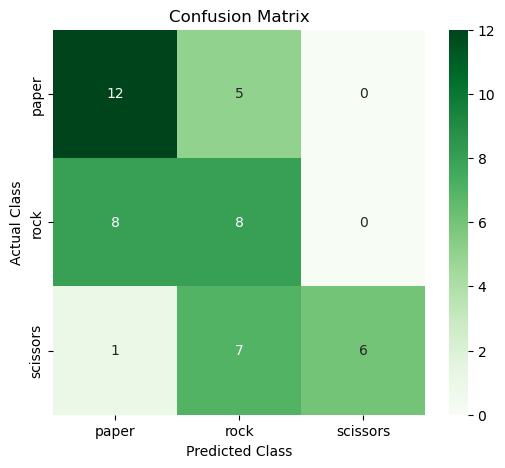

In [59]:
incorrect_indices_personalized = np.where(y_pred_personalized != y_personalized)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_personalized)} out of {len(y_personalized)}")
p=[('Predicted', x)  for x in class_names]
b=[('Actual', x)  for x in class_names]
df = pd.DataFrame(result_personalized, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model1_cf=np.array(pd.DataFrame(result_personalized,columns=class_names,index=class_names))
plt.figure(figsize=(6,5))
sns.heatmap(result_personalized, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted label: rock
Actual label: scissors


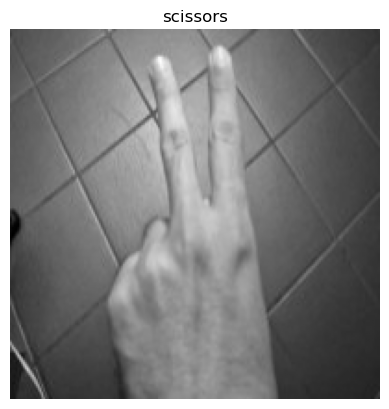

In [60]:
for images, labels in personalized_data.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_2.predict(image[None, ...])
    

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()
    

In [61]:
#calculate performance metrics for personalized data
p_true_pos=np.diag(result_personalized)
p_false_pos=np.sum(result_personalized, axis=0)-p_true_pos
p_false_neg=np.sum(result_personalized, axis=1)-p_true_pos
p_true_neg=np.sum(result_personalized)-p_true_pos-p_false_pos-p_false_neg

p_precision =p_true_pos / (p_true_pos + p_false_pos)
p_recall =p_true_pos / (p_true_pos + p_false_neg)
p_accuracy = np.sum(p_true_pos) / np.sum(result_personalized)
p_f1_score = 2 * (p_precision * p_recall) / (p_precision + p_recall)
print(f'------------------------personalized data performance metrics------------------------')
print(f'precision = {np.mean(p_precision)}')
print(f'recall = {np.mean(p_recall)}')
print(f'accuracy = {p_accuracy}')
print(f'f1_score = {np.mean(p_f1_score)}')


------------------------personalized data performance metrics------------------------
precision = 0.6571428571428571
recall = 0.5448179271708684
accuracy = 0.5531914893617021
f1_score = 0.5586744639376219


<h3>Dataset with frequent rotations</h3>

In [66]:

personalized_data_b = tf.keras.utils.image_dataset_from_directory(
    "test-black-bg",
    seed=42,
    color_mode="grayscale",
    image_size=(200,200),
    batch_size=32
)

Found 70 files belonging to 3 classes.


In [67]:
y_personalized_b=[]
img_personalized_b=[]
y_pred_personalized_b=[]
for images, labels in personalized_data_b.unbatch():
    y_personalized_b.append(labels.numpy())
    img_personalized_b.append(images.numpy())
    y_pred_personalized_b.append(np.argmax(model_3.predict(images[None, ...])[0]))

y_personalized_b = np.array(y_personalized_b)
img_personalized_b = np.array(img_personalized_b)
y_pred_personalized_b = np.array(y_pred_personalized_b)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━

In [68]:
result_personalized_b=confusion_matrix(y_personalized_b, y_pred_personalized_b,labels=[0,1,2])



Incorrectly classified samples: 9 out of 70


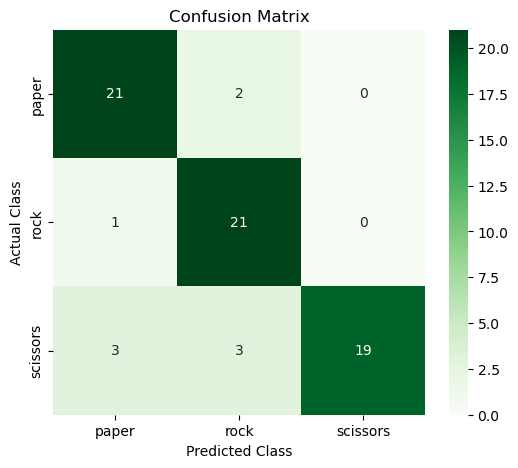

In [69]:
incorrect_indices_personalized_b = np.where(y_pred_personalized_b != y_personalized_b)[0]
print(f"Incorrectly classified samples: {len(incorrect_indices_personalized_b)} out of {len(y_personalized_b)}")
p=[('Predicted', x)  for x in class_names]
b=[('Actual', x)  for x in class_names]
df = pd.DataFrame(result_personalized_b, columns = pd.MultiIndex.from_tuples(p),
                 index=pd.MultiIndex.from_tuples(b))
model1_cf=np.array(pd.DataFrame(result_personalized_b,columns=class_names,index=class_names))
plt.figure(figsize=(6,5))
sns.heatmap(result_personalized_b, 
            annot=True, 
            fmt='d', 
            cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted label: paper
Actual label: paper


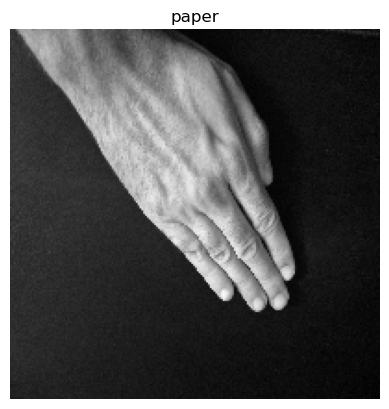

In [70]:
for images, labels in personalized_data_b.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_3.predict(image[None, ...])
    

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

In [71]:
#calculate performance metrics for personalized data
p_true_pos_b=np.diag(result_personalized_b)
p_false_pos_b=np.sum(result_personalized_b, axis=0)-p_true_pos_b
p_false_neg_b=np.sum(result_personalized_b, axis=1)-p_true_pos_b
p_true_neg_b=np.sum(result_personalized_b)-p_true_pos_b-p_false_pos_b-p_false_neg_b

p_precision_b =p_true_pos_b / (p_true_pos_b + p_false_pos_b)
p_recall_b =p_true_pos_b / (p_true_pos_b + p_false_neg_b)
p_accuracy_b = np.sum(p_true_pos_b) / np.sum(result_personalized_b)
p_f1_score_b = 2 * (p_precision_b * p_recall_b) / (p_precision_b + p_recall_b)
print(f'------------------------personalized data performance metrics------------------------')
print(f'precision = {np.mean(p_precision_b)}')
print(f'recall = {np.mean(p_recall_b)}')
print(f'accuracy = {p_accuracy_b}')
print(f'f1_score = {np.mean(p_f1_score_b)}')

------------------------personalized data performance metrics------------------------
precision = 0.8825641025641026
recall = 0.875862977602108
accuracy = 0.8714285714285714
f1_score = 0.8712121212121212


In [49]:

if not os.path.exists("model_1.keras"):
        model_1.save("model_1.keras")
if not os.path.exists("model_2.keras"):
        model_2.save("model_2.keras")
if not os.path.exists("model_3.keras"):
        model_3.save("model_3.keras")